# Task 4 — Customer Churn & Retention Analysis

**Dataset:** Telco Customer Churn (IBM sample / BlastChar version), 7,043 customers.

**Goal:** Analyze why customers leave, identify high-risk groups, and convert findings into
practical retention recommendations.

**Flow:** Data Analysis → Statistical Evidence → Business Insight → Recommendation

**Constraint:** No machine-learning prediction model is built for this task — only descriptive
analysis, hypothesis tests, and rule-based segmentation.


## 1. Dataset & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('telco.csv')
print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [3]:
# Missing values, duplicates, data types
print("Missing values per column:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("\nFull-row duplicates:", df.duplicated().sum())
print("Duplicate customerID:", df['customerID'].duplicated().sum())
print("\nTotalCharges dtype:", df['TotalCharges'].dtype)
print("Blank/whitespace TotalCharges values:", (df['TotalCharges'].astype(str).str.strip() == '').sum())

Missing values per column:
 Series([], dtype: int64)

Full-row duplicates: 0
Duplicate customerID: 0

TotalCharges dtype: str
Blank/whitespace TotalCharges values: 11


In [4]:
df.describe(include='number')

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### Data cleaning — what was changed and why

- **`TotalCharges`** was stored as text (`object`) and contained 11 blank/whitespace values instead
  of numbers. Pandas' `.isnull()` misses these because they are empty strings, not `NaN`. All 11
  blank rows have **`tenure == 0`** — brand-new customers who have not been billed yet — so the
  correct value is **0**, not a missing value to impute. Converted the column to numeric and filled
  those 11 rows with 0.
- **`SeniorCitizen`** is stored as `0`/`1` (int) rather than `Yes`/`No` like the other Yes/No
  columns. Kept as-is for the statistical tests (numeric is fine for grouping), but noted here since
  it's a type inconsistency worth documenting.
- No full-row duplicates and no duplicate `customerID`s were found, so no rows were dropped.


In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)
df['ChurnFlag'] = (df['Churn'] == 'Yes').astype(int)

assert df['TotalCharges'].isnull().sum() == 0
print("TotalCharges cleaned. New dtype:", df['TotalCharges'].dtype)
print("Rows where tenure==0:", (df['tenure'] == 0).sum(), "| Their TotalCharges values:", df.loc[df['tenure']==0, 'TotalCharges'].unique())

TotalCharges cleaned. New dtype: float64
Rows where tenure==0: 11 | Their TotalCharges values: [0.]


## 2. Churn Analysis

### 2.1 Overall churn

In [6]:
total_customers = len(df)
churned_customers = df['ChurnFlag'].sum()
retained_customers = total_customers - churned_customers
churn_rate = churned_customers / total_customers * 100

print(f"Total customers:    {total_customers:,}")
print(f"Churned customers:  {churned_customers:,}")
print(f"Retained customers: {retained_customers:,}")
print(f"Churn rate:         {churn_rate:.2f}%")

Total customers:    7,043
Churned customers:  1,869
Retained customers: 5,174
Churn rate:         26.54%


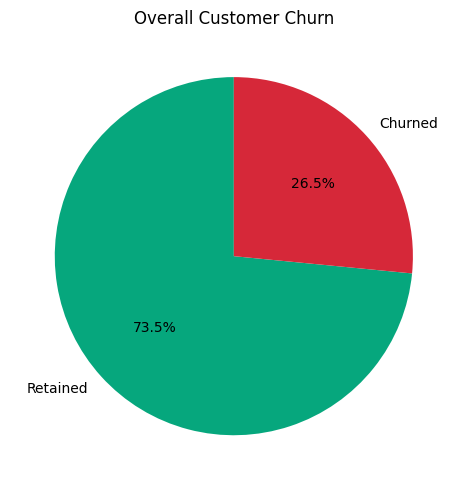

In [7]:
fig, ax = plt.subplots(figsize=(5,5))
ax.pie([retained_customers, churned_customers], labels=['Retained', 'Churned'],
       autopct='%1.1f%%', colors=['#06A77D', '#D62839'], startangle=90)
ax.set_title('Overall Customer Churn')
plt.tight_layout()
plt.savefig('chart_overall_churn.png', dpi=150)
plt.show()

**Interpretation:** Just over a quarter of customers (26.54%) have churned — a substantial share for a subscription business, and high enough that even modest reductions translate into meaningful revenue retained.

### 2.2 Churn by contract type

In [8]:
contract_churn = df.groupby('Contract')['ChurnFlag'].agg(Count='count', ChurnRate='mean')
contract_churn['ChurnRate'] = (contract_churn['ChurnRate'] * 100).round(2)
contract_churn = contract_churn.sort_values('ChurnRate', ascending=False)
contract_churn

,Count,ChurnRate
Contract,,
Month-to-month,3875,42.71
One year,1473,11.27
Two year,1695,2.83


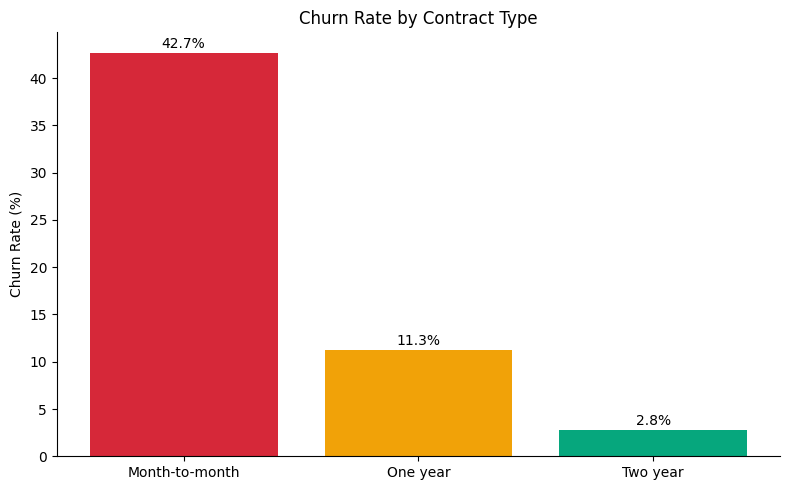

In [9]:
fig, ax = plt.subplots()
bars = ax.bar(contract_churn.index, contract_churn['ChurnRate'], color=['#D62839','#F1A208','#06A77D'])
ax.set_ylabel('Churn Rate (%)')
ax.set_title('Churn Rate by Contract Type')
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f"{bar.get_height():.1f}%", ha='center')
plt.tight_layout()
plt.savefig('chart_churn_by_contract.png', dpi=150)
plt.show()

**Interpretation:** Month-to-month customers churn at **42.7%**, roughly 4x the One-year rate (11.3%) and 15x the Two-year rate (2.8%) — contract length is the single strongest churn driver visible in this dataset.

### 2.3 Churn by tenure group

In [10]:
bins = [-1, 12, 24, 48, 999]
labels = ['0-12', '13-24', '25-48', '49+']
df['TenureGroup'] = pd.cut(df['tenure'], bins=bins, labels=labels)

tenure_churn = df.groupby('TenureGroup', observed=True)['ChurnFlag'].agg(Count='count', ChurnRate='mean')
tenure_churn['ChurnRate'] = (tenure_churn['ChurnRate'] * 100).round(2)
tenure_churn

,Count,ChurnRate
TenureGroup,,
0-12,2186,47.44
13-24,1024,28.71
25-48,1594,20.39
49+,2239,9.51


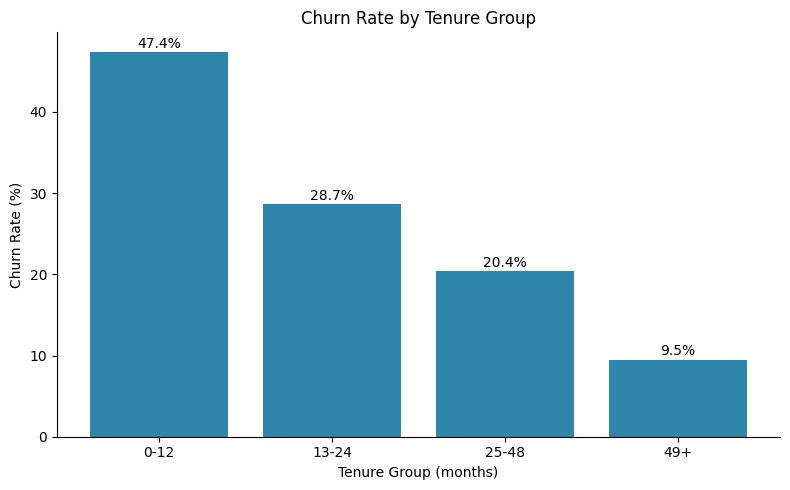

In [11]:
fig, ax = plt.subplots()
bars = ax.bar(tenure_churn.index, tenure_churn['ChurnRate'], color='#2E86AB')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Tenure Group (months)')
ax.set_title('Churn Rate by Tenure Group')
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f"{bar.get_height():.1f}%", ha='center')
plt.tight_layout()
plt.savefig('chart_churn_by_tenure.png', dpi=150)
plt.show()

**Interpretation:** Churn risk falls steadily with tenure — customers in their first year churn at **47.4%**, almost 5x the rate of customers with 49+ months of tenure (9.5%). The **0-12 month** group is the highest-risk tenure band.

### 2.4 Monthly charges — churned vs. retained

In [12]:
mc_compare = df.groupby('Churn')['MonthlyCharges'].mean().round(2)
mc_compare

Churn
No     61.27
Yes    74.44
Name: MonthlyCharges, dtype: float64

/tmp/ipykernel_138/1090207710.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([df[df['Churn']=='No']['MonthlyCharges'], df[df['Churn']=='Yes']['MonthlyCharges']],


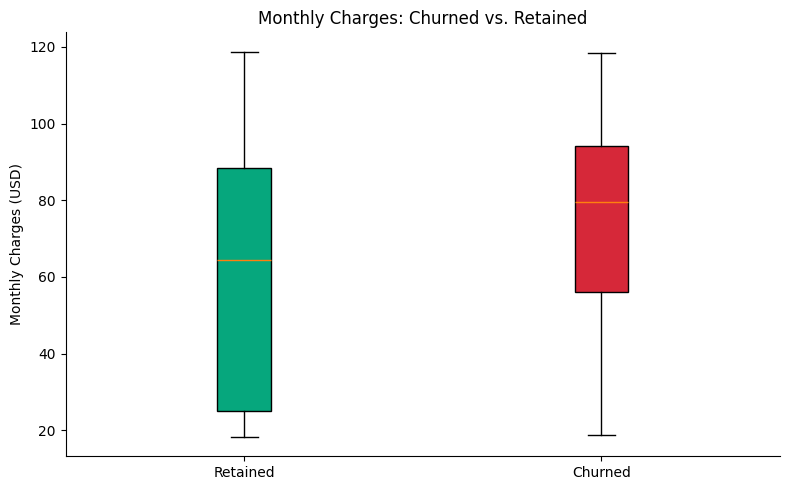

In [13]:
fig, ax = plt.subplots()
bp = ax.boxplot([df[df['Churn']=='No']['MonthlyCharges'], df[df['Churn']=='Yes']['MonthlyCharges']],
                 labels=['Retained', 'Churned'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['#06A77D', '#D62839']):
    patch.set_facecolor(color)
ax.set_ylabel('Monthly Charges (USD)')
ax.set_title('Monthly Charges: Churned vs. Retained')
plt.tight_layout()
plt.savefig('chart_monthly_charges_churn.png', dpi=150)
plt.show()

**Interpretation:** Churned customers pay **$74.44/month on average**, noticeably more than retained customers at **$61.27/month** — customers who leave tend to be on pricier plans, not cheaper ones.

### 2.5 Churn by payment method

In [14]:
payment_churn = df.groupby('PaymentMethod')['ChurnFlag'].agg(Count='count', ChurnRate='mean')
payment_churn['ChurnRate'] = (payment_churn['ChurnRate'] * 100).round(2)
payment_churn = payment_churn.sort_values('ChurnRate', ascending=False)
payment_churn

,Count,ChurnRate
PaymentMethod,,
Electronic check,2365,45.29
Mailed check,1612,19.11
Bank transfer (automatic),1544,16.71
Credit card (automatic),1522,15.24


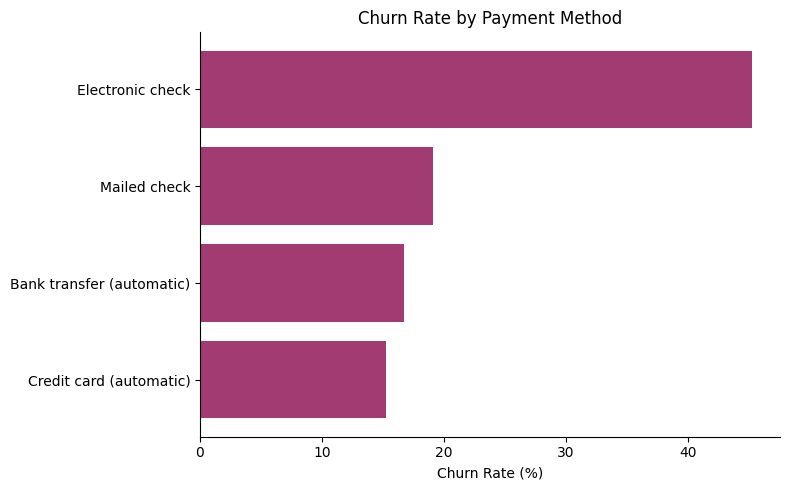

In [15]:
fig, ax = plt.subplots()
bars = ax.barh(payment_churn.index[::-1], payment_churn['ChurnRate'][::-1], color='#A23B72')
ax.set_xlabel('Churn Rate (%)')
ax.set_title('Churn Rate by Payment Method')
plt.tight_layout()
plt.savefig('chart_churn_by_payment.png', dpi=150)
plt.show()

**Interpretation:** Electronic check users churn at **45.3%** — roughly 3x the rate of automatic payment methods (bank transfer 16.7%, credit card 15.2%) — manual, non-automated billing is strongly associated with higher churn.

### 2.6 Churn by service — Internet Service & Tech Support

In [16]:
internet_churn = df.groupby('InternetService')['ChurnFlag'].agg(Count='count', ChurnRate='mean')
internet_churn['ChurnRate'] = (internet_churn['ChurnRate'] * 100).round(2)

techsupport_churn = df.groupby('TechSupport')['ChurnFlag'].agg(Count='count', ChurnRate='mean')
techsupport_churn['ChurnRate'] = (techsupport_churn['ChurnRate'] * 100).round(2)

print(internet_churn)
print()
print(techsupport_churn)

                 Count  ChurnRate
InternetService                  
DSL               2421      18.96
Fiber optic       3096      41.89
No                1526       7.40

                     Count  ChurnRate
TechSupport                          
No                    3473      41.64
No internet service   1526       7.40
Yes                   2044      15.17


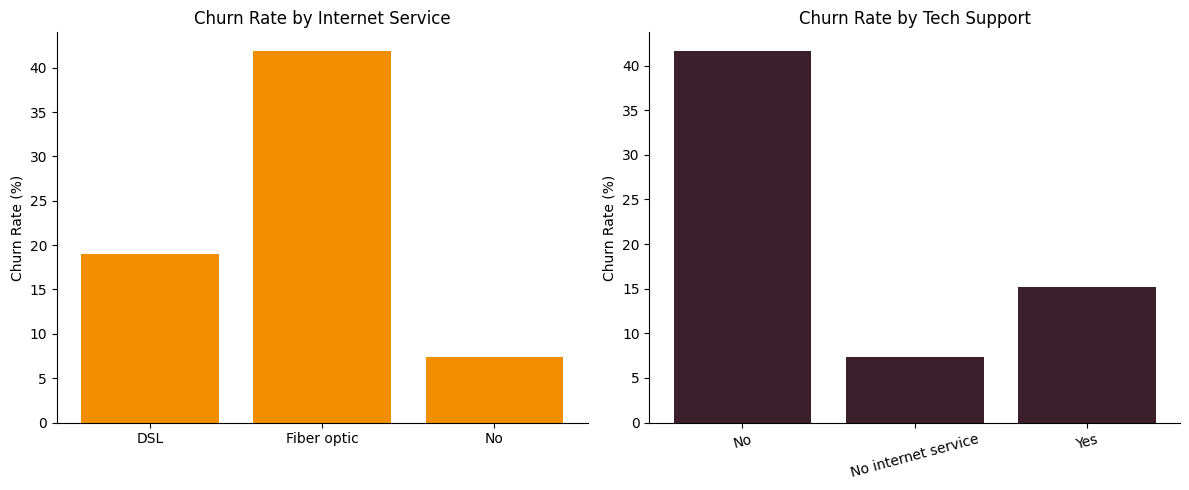

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(internet_churn.index, internet_churn['ChurnRate'], color='#F18F01')
axes[0].set_title('Churn Rate by Internet Service')
axes[0].set_ylabel('Churn Rate (%)')

axes[1].bar(techsupport_churn.index, techsupport_churn['ChurnRate'], color='#3B1F2B')
axes[1].set_title('Churn Rate by Tech Support')
axes[1].set_ylabel('Churn Rate (%)')
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig('chart_churn_by_services.png', dpi=150)
plt.show()

**Interpretation:** Fiber optic customers churn at **41.9%**, far above DSL (19.0%) or no internet (7.4%) — likely reflecting price sensitivity, since fiber is the priciest tier. Customers **without** Tech Support churn at **41.6%** vs. just **15.2%** for those with it, suggesting Tech Support meaningfully improves retention.

## 3. Statistical Analysis (α = 0.05)

### Test 1 — Contract vs. Churn (Chi-Square Test of Independence)

- H0: Contract type and churn are independent.
- H1: Contract type and churn are associated.

In [18]:
contingency = pd.crosstab(df['Contract'], df['Churn'])
chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency)

print(f"Chi-square statistic: {chi2_stat:.2f}")
print(f"Degrees of freedom:   {dof}")
print(f"p-value:              {p_value:.2e}")
decision = "Reject H0" if p_value < 0.05 else "Fail to reject H0"
print(f"Decision (α=0.05):    {decision}")

Chi-square statistic: 1184.60
Degrees of freedom:   2
p-value:              5.86e-258
Decision (α=0.05):    Reject H0


**Interpretation:** With p ≈ 5.86e-258 (far below α = 0.05), we **reject H0**. Contract type and churn are strongly associated — this statistically confirms the pattern seen in Section 2.2, where month-to-month customers churn far more than one- or two-year contract holders.

### Test 2 — Monthly Charges vs. Churn (Independent Samples T-Test)

- H0: Mean monthly charges are equal for churned and retained customers.
- H1: Mean monthly charges differ between churned and retained customers.

In [19]:
churned_mc = df[df['Churn'] == 'Yes']['MonthlyCharges']
retained_mc = df[df['Churn'] == 'No']['MonthlyCharges']

t_stat, p_value_t = stats.ttest_ind(churned_mc, retained_mc, equal_var=False)

print(f"Mean (Churned):  ${churned_mc.mean():.2f}")
print(f"Mean (Retained): ${retained_mc.mean():.2f}")
print(f"T-statistic:     {t_stat:.2f}")
print(f"p-value:         {p_value_t:.2e}")
decision_t = "Reject H0" if p_value_t < 0.05 else "Fail to reject H0"
print(f"Decision (α=0.05): {decision_t}")

Mean (Churned):  $74.44
Mean (Retained): $61.27
T-statistic:     18.41
p-value:         8.59e-73
Decision (α=0.05): Reject H0


**Interpretation:** With p ≈ 8.59e-73 (far below α = 0.05), we **reject H0**. Churned customers pay significantly more per month ($74.44) than retained customers ($61.27) — the price difference seen in Section 2.4 is statistically significant, not due to chance.

## 4. Customer Segmentation & Revenue at Risk

Four mutually-exclusive, rule-based segments built from **tenure** and **monthly charges**
(priority order below), with **churn** used to evaluate each segment's outcome rather than to
define it — this avoids circular segments where churn rate is trivially 0% or 100%.

1. **New** — tenure ≤ 12 months
2. **High-Value** — tenure > 12 months and MonthlyCharges ≥ $70
3. **Loyal** — tenure > 24 months and MonthlyCharges < $70
4. **Standard** — everything else (tenure 13-24 months, MonthlyCharges < $70)


In [20]:
def assign_segment(row):
    if row['tenure'] <= 12:
        return 'New'
    elif row['MonthlyCharges'] >= 70:
        return 'High-Value'
    elif row['tenure'] > 24:
        return 'Loyal'
    else:
        return 'Standard'

df['Segment'] = df.apply(assign_segment, axis=1)

segment_summary = df.groupby('Segment').apply(
    lambda g: pd.Series({
        'CustomerCount': len(g),
        'AvgTenure': g['tenure'].mean(),
        'AvgMonthlyCharges': g['MonthlyCharges'].mean(),
        'ChurnRate_%': g['ChurnFlag'].mean() * 100,
        'RevenueAtRisk_$': g.loc[g['Churn'] == 'Yes', 'MonthlyCharges'].sum()
    }),
    include_groups=False
).round(2).sort_values('ChurnRate_%', ascending=False)

segment_summary

,CustomerCount,AvgTenure,AvgMonthlyCharges,ChurnRate_%,RevenueAtRisk_$
Segment,,,,,
New,2186.0,4.73,56.10,47.44,68954.25
High-Value,2711.0,47.04,92.52,24.90,62759.70
Standard,544.0,18.40,38.45,13.79,3591.60
Loyal,1602.0,50.01,38.55,5.12,3825.30


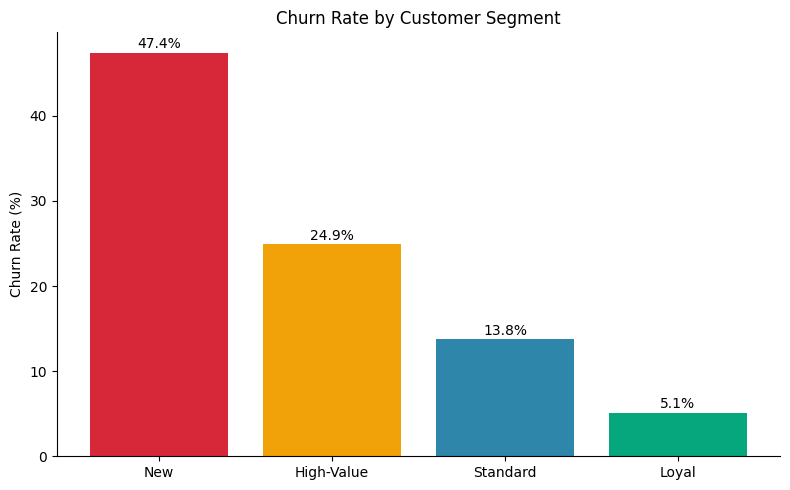

In [21]:
fig, ax = plt.subplots()
colors = {'New': '#D62839', 'High-Value': '#F1A208', 'Standard': '#2E86AB', 'Loyal': '#06A77D'}
bars = ax.bar(segment_summary.index, segment_summary['ChurnRate_%'],
              color=[colors[s] for s in segment_summary.index])
ax.set_ylabel('Churn Rate (%)')
ax.set_title('Churn Rate by Customer Segment')
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f"{bar.get_height():.1f}%", ha='center')
plt.tight_layout()
plt.savefig('chart_churn_by_segment.png', dpi=150)
plt.show()

In [22]:
total_revenue_at_risk = df.loc[df['Churn'] == 'Yes', 'MonthlyCharges'].sum()
total_monthly_revenue = df['MonthlyCharges'].sum()
pct_at_risk = total_revenue_at_risk / total_monthly_revenue * 100

print(f"Total Monthly Revenue at Risk (churned customers' MonthlyCharges): ${total_revenue_at_risk:,.2f}")
print(f"Total Monthly Revenue (all customers):                            ${total_monthly_revenue:,.2f}")
print(f"Share of monthly revenue at risk:                                 {pct_at_risk:.2f}%")

Total Monthly Revenue at Risk (churned customers' MonthlyCharges): $139,130.85
Total Monthly Revenue (all customers):                            $456,116.60
Share of monthly revenue at risk:                                 30.50%


**Which segment needs the most retention attention?**

The **New** segment (tenure ≤ 12 months): it has both the **highest churn rate (47.0%)** of any
segment and the **largest revenue at risk ($68,954/month)** — more than the High-Value segment
despite New customers paying less individually, simply because there are more of them (2,186
customers) and nearly half leave. This segment functionally is the "High-Risk" group referenced in
the task brief: newly-acquired customers who haven't yet formed a habit or committed to a longer
contract. The High-Value segment (25.0% churn, $62,760/month at risk) is the second priority —
smaller in count but each lost customer is worth more individually.

## 5. Data export for Power BI

Exports the cleaned, segmented dataset and a KPI summary for the Power BI dashboard.

In [23]:
df.to_csv('power_bi/telco_churn_clean.csv', index=False)

kpi_summary = pd.DataFrame([{
    'TotalCustomers': total_customers,
    'ChurnedCustomers': int(churned_customers),
    'ChurnRate_%': round(churn_rate, 2),
    'AvgMonthlyCharges': round(df['MonthlyCharges'].mean(), 2),
    'RevenueAtRisk_$': round(total_revenue_at_risk, 2)
}])
kpi_summary.to_csv('power_bi/kpi_summary.csv', index=False)
kpi_summary

,TotalCustomers,ChurnedCustomers,ChurnRate_%,AvgMonthlyCharges,RevenueAtRisk_$
0,7043,1869,26.54,64.76,139130.85


## 6. Findings & Recommendations

### Key Findings

1. **Overall churn is 26.54%** (1,869 of 7,043 customers) — a material share of the customer base.
2. **Contract length is the strongest churn driver.** Month-to-month churn (42.7%) is roughly 4x
   One-year (11.3%) and 15x Two-year (2.8%); confirmed statistically significant (χ² test,
   p < 0.001).
3. **Tenure and churn are inversely related.** First-year customers churn at 47.4% vs. 9.5% for
   customers with 49+ months tenure — risk is front-loaded in the relationship.
4. **Churned customers pay more, not less** — $74.44/month average vs. $61.27/month for retained
   customers, a statistically significant gap (t-test, p < 0.001). Price is a churn factor, but it's
   not simply "cheap customers leave."
5. **Manual payment and missing services compound risk.** Electronic check users churn at 45.3%
   (vs. ~15-17% for automatic payments), and customers without Tech Support churn at 41.6% (vs.
   15.2% with it) — these are two independent, addressable risk factors.

### Recommendations

1. **Incentivize contract upgrades.** Since month-to-month churn (42.7%) dwarfs annual/biennial
   rates, offer a discount or bundled perk for month-to-month customers who switch to a one-year
   contract — directly targets Finding 2, the single strongest churn driver found.
2. **Build a structured first-year onboarding/retention program.** With 47.4% of 0-12 month
   customers churning (Finding 3), front-load engagement — check-in calls, first-90-days offers,
   proactive support — during the highest-risk tenure window rather than spreading effort evenly.
3. **Review fiber/high-tier pricing and value communication.** Since churned customers pay $13/month
   more on average and Fiber optic churn (41.9%) is the highest of any internet tier (Finding 4),
   test whether bundling a retention perk (e.g., free add-on) with the priciest plans reduces
   price-driven cancellations.
4. **Push customers off electronic check onto automatic payment.** Electronic check churn (45.3%)
   is roughly 3x automatic methods (Finding 5) — offer a small discount or incentive for switching
   to bank transfer or credit card autopay, a low-cost lever with a clear, data-backed payoff.
5. **Make Tech Support a retention lever, not just an upsell.** Customers without Tech Support churn
   at 41.6% vs. 15.2% with it (Finding 5) — bundle a free trial of Tech Support into the first-year
   onboarding program (Recommendation 2) for New-segment customers, since this segment carries both
   the highest churn rate and the most revenue at risk ($68,954/month, Section 4).
